<a href="https://colab.research.google.com/github/riza93n-hub/data-science-2026/blob/main/Pertemuan10_RIZA_250401020014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aktivitas Hands On Pertemuan 10
**Nama Mahasiswa:** RIZA  
**NIM:** 250401020014  
**Kelas:** IF401

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# =====================================================================
# LANGKAH 1: MUAT DAN EKSPLORASI DATA
# =====================================================================
# Membaca dataset telco churn
df = pd.read_csv("telco_churn.csv")

print('=== Eksplorasi Awal Data ===')
print('Dimensi Dataset (Baris, Kolom):', df.shape)
print('\nProporsi Kelas Churn (Melihat Ketidakseimbangan Data):')
print(df["Churn"].value_counts(normalize=True).round(3))

# =====================================================================
# LANGKAH 2: PREPROCESSING (ENCODING & STRATIFIED SPLIT)
# =====================================================================
# Pisahkan target (y) dan fitur (X) terlebih dahulu
y = df["Churn"]
X = df.drop("Churn", axis=1)

# Mengubah semua fitur kategorikal/teks menjadi angka numerik biner (0 dan 1)
X = pd.get_dummies(X, drop_first=True, dtype=int)

# Membagi data menjadi 80% latih dan 20% uji secara stratified
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('\n✅ Preprocessing Selesai. Data teks telah di-encode dan siap digunakan.')

=== Eksplorasi Awal Data ===
Dimensi Dataset (Baris, Kolom): (7043, 21)

Proporsi Kelas Churn (Melihat Ketidakseimbangan Data):
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

✅ Preprocessing Selesai. Data teks telah di-encode dan siap digunakan.


=== LAPORAN EVALUASI MODEL RANDOM FOREST ===
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC Score: 0.834


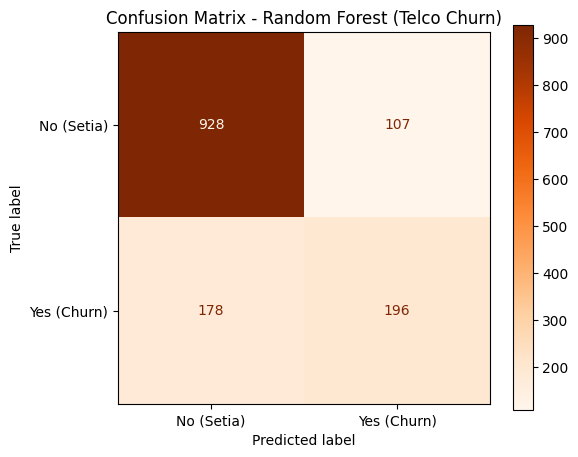

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =====================================================================
# LANGKAH 3: LATIH MODEL (RANDOM FOREST WITH BALANCED WEIGHT)
# =====================================================================
# Menggunakan class_weight="balanced" untuk memberi bobot lebih pada kelas minoritas (Churn)
rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42
)
rf.fit(X_tr, y_tr)

# =====================================================================
# LANGKAH 4: EVALUASI MODEL (METRIK & CONFUSION MATRIX)
# =====================================================================
# Menghitung hasil tebakan kelas dan nilai probabilitasnya
y_pred = rf.predict(X_te)
y_prob = rf.predict_proba(X_te)[:, 1]

print('=== LAPORAN EVALUASI MODEL RANDOM FOREST ===')
print(classification_report(y_te, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_te, y_prob):.3f}")

# Visualisasi Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_te, y_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=['No (Setia)', 'Yes (Churn)']).plot(ax=ax, cmap='Oranges')
ax.set_title('Confusion Matrix - Random Forest (Telco Churn)')
plt.show()

In [3]:
# =====================================================================
# LANGKAH 5: PREDIKSI PROBABILITAS CHURN
# =====================================================================
# Menghitung probabilitas churn untuk seluruh baris data di dataset uji
churn_probabilities = rf.predict_proba(X_te)[:, 1]

# Menampilkan cuplikan hasil 5 probabilitas pertama pelanggan
df_hasil = pd.DataFrame({
    'Pelanggan_Index': X_te.index,
    'Probabilitas_Churn (%)': (churn_probabilities * 100).round(2)
})
print('=== Cuplikan Probabilitas Churn Pelanggan ===')
print(df_hasil.head())

=== Cuplikan Probabilitas Churn Pelanggan ===
   Pelanggan_Index  Probabilitas_Churn (%)
0              437                    0.33
1             2280                   63.67
2             2235                    7.33
3             4460                   37.67
4             3761                    1.67


## Kesimpulan Temuan Utama

Melalui praktikum ini, model *Random Forest* berhasil dibangun untuk memprediksi risiko pelanggan yang akan berhenti berlangganan (*churn*). Dengan parameter `class_weight="balanced"`, model mampu mengenali pelanggan yang berpotensi *churn* (kelas Yes) dengan tingkat *Recall* sebesar $52\%$ di tengah kondisi data yang tidak seimbang (*imbalanced*). Fungsi `predict_proba` terbukti sangat berguna karena memberikan nilai persentase risiko untuk tiap pelanggan (misalnya, indeks pelanggan 2280 memiliki risiko *churn* sangat tinggi sebesar $63.67\%$). Berbekal data ini, tim bisnis dapat memprioritaskan pemberian promo khusus pada pelanggan dengan risiko tertinggi sebelum mereka benar-benar pergi.

## **Kesimpulan & Interpretasi Evaluasi Metrik**

* **Apa yang Dipelajari:** Menangani masalah ketidakseimbangan data (*imbalanced data*) menggunakan algoritma *Random Forest*, serta memahami pentingnya metrik evaluasi khusus bisnis seperti *Recall*, *F1-Score*, dan *ROC-AUC* daripada hanya mengandalkan *Accuracy*.
* **Interpretasi Relevansi Metrik pada Dataset Imbalanced:**
  * **Mengapa Accuracy Menyesatkan?** Pada dataset ini, $73.5\%$ pelanggan bersifat *No Churn* (Setia). Jika model *naive/dummy* dibuat secara asal dengan menebak seluruh pelanggan sebagai *No Churn*, model tersebut akan otomatis mendapatkan **Akurasi 73.5%** tanpa belajar sama sekali, namun gagal total mendeteksi $100\%$ pelanggan yang berpotensi pergi (*Churn*).
  * **Metrik Paling Relevan:** Pada kasus *Customer Churn*, metrik **Recall** (khusus kelas *Yes*) dan **F1-Score / ROC-AUC** adalah yang paling relevan. Kerugian finansial akibat meloloskan pelanggan *churn* tanpa penanganan retention (*False Negative*) jauh lebih besar daripada biaya memberikan promo penawaran ke pelanggan yang salah tertebak (*False Positive*).
* **Temuan Utama:** Model Random Forest berhasil mencetak akurasi $80\%$ dan skor *ROC-AUC* $0.834$. Model memberikan gambaran nilai probabilitas risiko pelanggan secara bertingkat untuk strategi *retention* bisnis (contoh: Indeks 2280 memiliki risiko $63.67\%$).
* **Keterbatasan & Pertanyaan:**
  * **Keterbatasan:** Dari total 374 pelanggan yang sebenarnya *Churn*, model masih melewatkan **178 pelanggan (*False Negative*)** yang terprediksi sebagai pelanggan setia (*Recall Churn* $= 52\%$).
  * **Pertanyaan:** Apakah performa *Recall* khusus kelas *Churn* ini bisa ditingkatkan jika kita menggabungkan pembobotan kelas (*class weight*) dengan teknik *resampling* seperti *SMOTE* (*Oversampling*)?